In [1]:

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

In [2]:
# open dataframe
path_ys = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/results/ys/mech_result/df_results_ting_results.csv'
df = pd.read_csv(path_ys)
df.head()

,file_path,file_id,curve_idx,kcanti,defl_sens,scan_size_x_y_m,map_size_x_y_pixels,hertz_ind_geometry,hertz_tip_parameter,hertz_apply_BEC,...,ting_smooth_w,ting_idx_tm,ting_MAE,ting_MSE,ting_RMSE,ting_Rsquared,ting_chisq,ting_redchi,ting_v0t_app_vel,ting_v0r_ret_vel
0,/Users/yogehs/Documents/ATIP_PhD/CTC_mech_data...,fcurve___2025.03.12_18.40.08.12.tdms,0,0.063,38.8,"[0.0, 0.0]","[0, 0]",paraboloid,5.600000e-08,False,...,5.0,100.0,1.229773e-10,2.409171e-20,1.552151e-10,0.440655,-1.143186e-07,-2.857964e-08,0.000293,-0.000058
1,/Users/yogehs/Documents/ATIP_PhD/CTC_mech_data...,fcurve___2025.03.12_18.46.37.67.tdms,0,0.063,38.8,"[0.0, 0.0]","[0, 0]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/Users/yogehs/Documents/ATIP_PhD/CTC_mech_data...,fcurve___2025.03.12_18.40.27.28.tdms,0,0.063,38.8,"[0.0, 0.0]","[0, 0]",paraboloid,5.600000e-08,False,...,5.0,107.0,1.033836e-10,4.638578e-20,2.153736e-10,0.820278,-2.422852e-08,-6.057129e-09,0.000622,0.000215
3,/Users/yogehs/Documents/ATIP_PhD/CTC_mech_data...,fcurve___2025.03.12_18.40.24.38.tdms,0,0.063,38.8,"[0.0, 0.0]","[0, 0]",paraboloid,5.600000e-08,False,...,5.0,108.0,5.427477e-11,1.490636e-20,1.220916e-10,0.863569,-1.081245e-08,-2.703112e-09,0.000587,0.000259
4,/Users/yogehs/Documents/ATIP_PhD/CTC_mech_data...,fcurve___2025.03.12_18.40.27.90.tdms,0,0.063,38.8,"[0.0, 0.0]","[0, 0]",paraboloid,5.600000e-08,False,...,5.0,123.0,1.528393e-11,3.959700e-20,1.989899e-10,0.808457,-2.239439e-07,-5.598597e-08,0.000509,0.000277


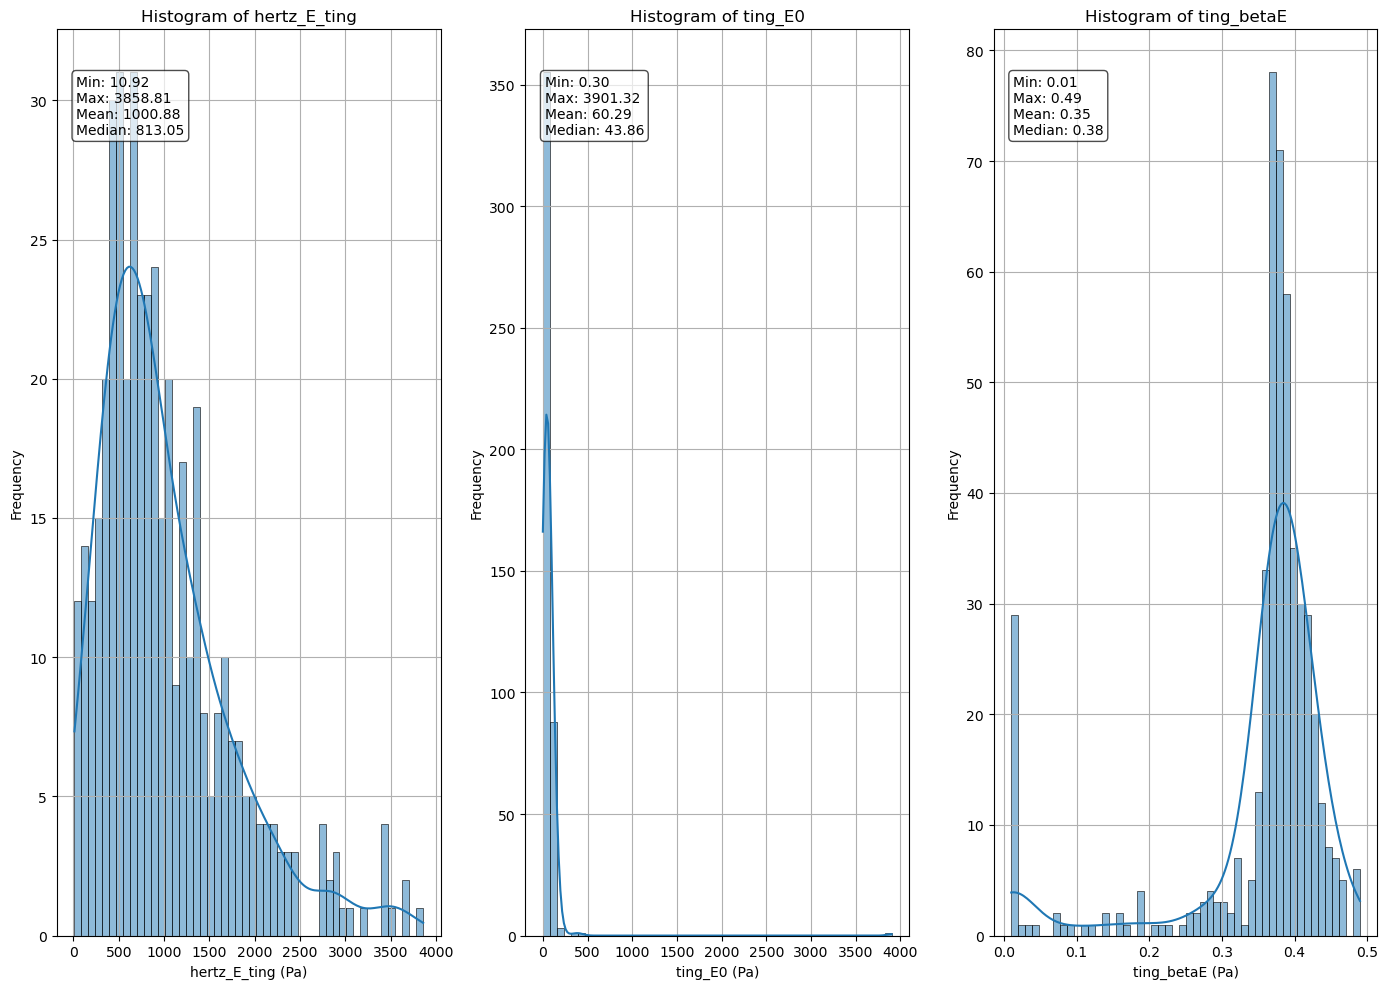

In [3]:
# open two dataframes and merge them in term of columns
path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/results/LV_ting_v3_ting_results.csv'
df1 = pd.read_csv(path_ting)
path_hertz = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/results/hertz_v2_AfterLorenzoFix_hertz_results.csv'

df2 = pd.read_csv(path_hertz)

# Merge and match each row from both dataframes based on file_id. Assuming both dataframes have a 'file_id' column
df_merged_1 = pd.merge(df1, df2, on='filepath', suffixes=('_ting', '_hertz'))
# df_merged.head()
keys_to_plot = ['hertz_E_ting', 'ting_E0', 'ting_betaE',]
maps.create_filtered_histogram(df_merged_1, keys_to_plot, filter_range=(0, 4000), bins=50)


### create map from fit parameters


In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'


In [5]:

# Map data collected on 3/11/2025 for characterizing the map times for fast approach vs normal approach
# map_path = r'D:\PSnex\psnex_map___2025.03.11_10.43.44.10\10um_PSBead.csv' # fast approach : 1
# map_path = r"D:\PSnex\psnex_map___2025.03.11_12.07.58.99\10um_PolySterine_conglomerate.csv" #fast approach" : 2
# map_path = r"D:\PSnex\psnex_map___2025.03.11_13.16.16.47\10um_PolySterine_conglomerate_smaller.csv" #fast approach : 3
# map_path = r"D:\PSnex\2025_11_03\psnex_map___2025.03.11_13.47.52.16\10um_PolySterine_conglomerate_smaller_NormalApproach.csv" # normal Approach : 4

## CTC 44 analysis 2025_03_12
map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_17.51.51.34'
path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_17.51.51.34/results/ting_fit_2025_oct_ting_results.csv'

map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.05.10.71'
path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.05.10.71/results/ting_fit_2025_oct_ting_results.csv'




#%%%%%% NEW STUFF %%%#####

map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54' #CTC44
map_path = '/Users/evillz/Data/article/psnex_map___2025.03.11_13.47.52.16' # bunch of cells together, cannot make fits!
map_path = '/Users/evillz/Data/psnex_map___2024.12.18_18.49.44.90' # 32x32 something but slanted... i think thp1
map_path = '/Users/evillz/Data/psnex_map___2024.11.22_14.48.26.59' # polysterine 10µm 32x32




###%%% SHIT##%%%
##%%%% Article
map_path = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/'
# map_path_csv = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/psnex_map___2025.05.30_17.44.50.71.csv’
path_ting = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/tingFit_2025_oct_ting_results.csv'


# open two dataframes and merge them in term of columns
# path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/results/LV_ting_v3_ting_results.csv'
# map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45' # CTC 44 PFQNM. THIS

# map_path = '/Users/evillz/Data/psnex_map___2024.11.22_15.23.01.16' # the great egg, cannot do fits because curves suck!, the great egg polysterine 10µm 64x64
# # map_path = '/Users/evillz/Data/psnex_map___2024.12.18_18.49.44.90'
# map_path = '/Users/evillz/Data/psnex_map___2024.10.15_16.31.06.47'
# map_path = '/Users/evillz/Data/CTC44/CTC_chirp_yogesh/psnex_map___2025.03.21_19.44.03.14'

# map_path ='/Users/evillz/Data/THP_LiveCells/2024_07_24/map0_thp1_fixated_cells_2'

saveSVG = False
lastColFirst = True


In [6]:
# print (map_path)
new_path = os.path.join(map_path, 'results')

if os.path.exists(new_path):
    print (f"Directory {new_path} exists.")
    svg_dir = new_path

Directory /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results exists.


In [7]:
# path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/results/ting_v1_psnex_map___2025.03.12_18.23.11.20_ting_results.csv'
# map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/'
map_name = os.path.basename(os.path.normpath(map_path))



In [8]:
# open CSV files
df_ting = pd.read_csv(path_ting)

df_ting.head()

,file_path,file_id,curve_idx,kcanti,defl_sens,hertz_ind_geometry,hertz_tip_parameter,hertz_apply_BEC,hertz_BEC_model,hertz_fit_hline_on_baseline,...,ting_smooth_w,ting_idx_tm,ting_MAE,ting_MSE,ting_RMSE,ting_Rsquared,ting_chisq,ting_redchi,ting_v0t_app_vel,ting_v0r_ret_vel
0,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_18.05.57.29.tdms,0,0.14,24.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_18.04.40.69.tdms,0,0.14,24.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.47.56.80.tdms,0,0.14,24.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.50.46.00.tdms,0,0.14,24.0,pyramid,35.0,False,NaN,False,...,5.0,232.0,-1.419109e-17,2.737634e-21,5.232240e-11,0.983636,-7.962516e-10,-1.990629e-10,0.00002,0.0001
4,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.47.53.01.tdms,0,0.14,24.0,pyramid,35.0,False,NaN,False,...,5.0,233.0,-2.265455e-20,1.418499e-20,1.191008e-10,0.902395,-2.246648e-09,-5.616619e-10,0.00002,0.0001


In [9]:
print (map_path)

/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/


In [10]:
df_dict_tdms, map_x_pix, map_y_pix, params = maps.load_map_file_square_tdms(map_path)
print (df_dict_tdms.columns)
df_dict_tdms.head()


# of files analyzed: 1024, closest shape: 32 x 32
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  M

,filepath,file_id,z_height_v,curve_index,x_index,y_index,z_height_um,x_pos_um,y_pos_um,z_height_um_zero
0,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.09.31.tdms,6.799683,0,0,0,40.798098,0.0000,0.0,8.999082
1,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.10.16.tdms,6.761810,1,1,0,40.570860,0.5685,0.0,9.226320
2,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.11.64.tdms,6.672760,2,2,0,40.036560,1.1370,0.0,9.760620
3,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.12.97.tdms,6.545746,3,3,0,39.274476,1.7055,0.0,10.522704
4,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.14.25.tdms,6.594543,4,4,0,39.567258,2.2740,0.0,10.229922


In [11]:
bool_error, mismatch_indices = maps.check_map_indice_integrity(df_dict_tdms, map_x_pix, map_y_pix)
if bool_error:
    x_pos_1d, y_pos_1d, curve_index = maps.generate_xy_map_positions(map_x_pix=map_x_pix, map_y_pix=map_y_pix)
    x_indices = x_pos_1d
    y_indices = y_pos_1d
    print ('Map indices were regenerated due to integrity error')   

    # sort mismatch indices based on time from file ID
    df_time = maps.compute_time_difference(map_path)

    # Remove duplicates from df_time based on filepath (keep first occurrence)
    df_time = df_time.drop_duplicates(subset='filepath', keep='first')

    

    # Merge based on filepath - this should now be 1:1
    df_merged_tdms = pd.merge(df_dict_tdms, df_time, on='filepath', how='left')

    # create copy of df_merged_tdms to avoid SettingWithCopyWarning
    df_merged_tdms_copy = df_merged_tdms.copy()

    # # merge def_ting to df_merged_tdms based on filepath
    df_merged_tdms_copy = pd.merge(df_merged_tdms_copy, df_ting, on='file_id', how='left')

    # # insert x_indices and y_indices and curve index into df_merged_tdms
    df_merged_tdms_copy['x_index'] = x_indices
    df_merged_tdms_copy['y_index'] = y_indices
    df_merged_tdms_copy['curve_index'] = curve_index

    # Check if we have the expected number of rows
    print(f"df_map rows: {len(df_dict_tdms)}")
    print(f"df_time rows: {len(df_time)}")
    print(f"df_merged_tdms rows: {len(df_merged_tdms)}")




79 Mismatched indices: [ 34  65  66  78  86  92 129 131 132 135]
Shape of x_pos_1d: (1024,)
Shape of y_pos_1d: (1024,)
Map indices were regenerated due to integrity error
Files processed: 1024, matches found: 1024

Time difference between first and last file HH:MM:SS:MS: 00:19:52:36
df_map rows: 1024
df_time rows: 1024
df_merged_tdms rows: 1024


In [12]:
df_merged_tdms_copy.head()

,filepath,file_id,z_height_v,curve_index,x_index,y_index,z_height_um,x_pos_um,y_pos_um,z_height_um_zero,...,ting_smooth_w,ting_idx_tm,ting_MAE,ting_MSE,ting_RMSE,ting_Rsquared,ting_chisq,ting_redchi,ting_v0t_app_vel,ting_v0r_ret_vel
0,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.09.31.tdms,6.799683,0,0,0,40.798098,0.0000,0.0,8.999082,...,5.0,25.0,-4.909087e-10,1.024436e-18,1.012144e-09,0.035498,4.291318e-07,1.072829e-07,0.00002,0.0001
1,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.10.16.tdms,6.761810,1,1,0,40.570860,0.5685,0.0,9.226320,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.11.64.tdms,6.672760,2,2,0,40.036560,1.1370,0.0,9.760620,...,5.0,230.0,-9.700853e-17,6.954709e-21,8.339490e-11,0.958222,-1.470277e-08,-3.675693e-09,0.00002,0.0001
3,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.12.97.tdms,6.545746,3,3,0,39.274476,1.7055,0.0,10.522704,...,5.0,228.0,1.227341e-10,4.934194e-20,2.221305e-10,0.852744,-2.079276e-07,-5.198191e-08,0.00002,0.0001
4,/Users/evillz/Data/article/2025_30_5/psnex_map...,fcurve___2025.05.30_17.46.14.25.tdms,6.594543,4,4,0,39.567258,2.2740,0.0,10.229922,...,5.0,227.0,2.220989e-10,1.130047e-19,3.361618e-10,0.726790,4.281429e-07,1.070357e-07,0.00002,0.0001


Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 14, zmin: 0.0
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/z_height_um_zero_psnex_map___2025.05.30_17.44.50.71.svg


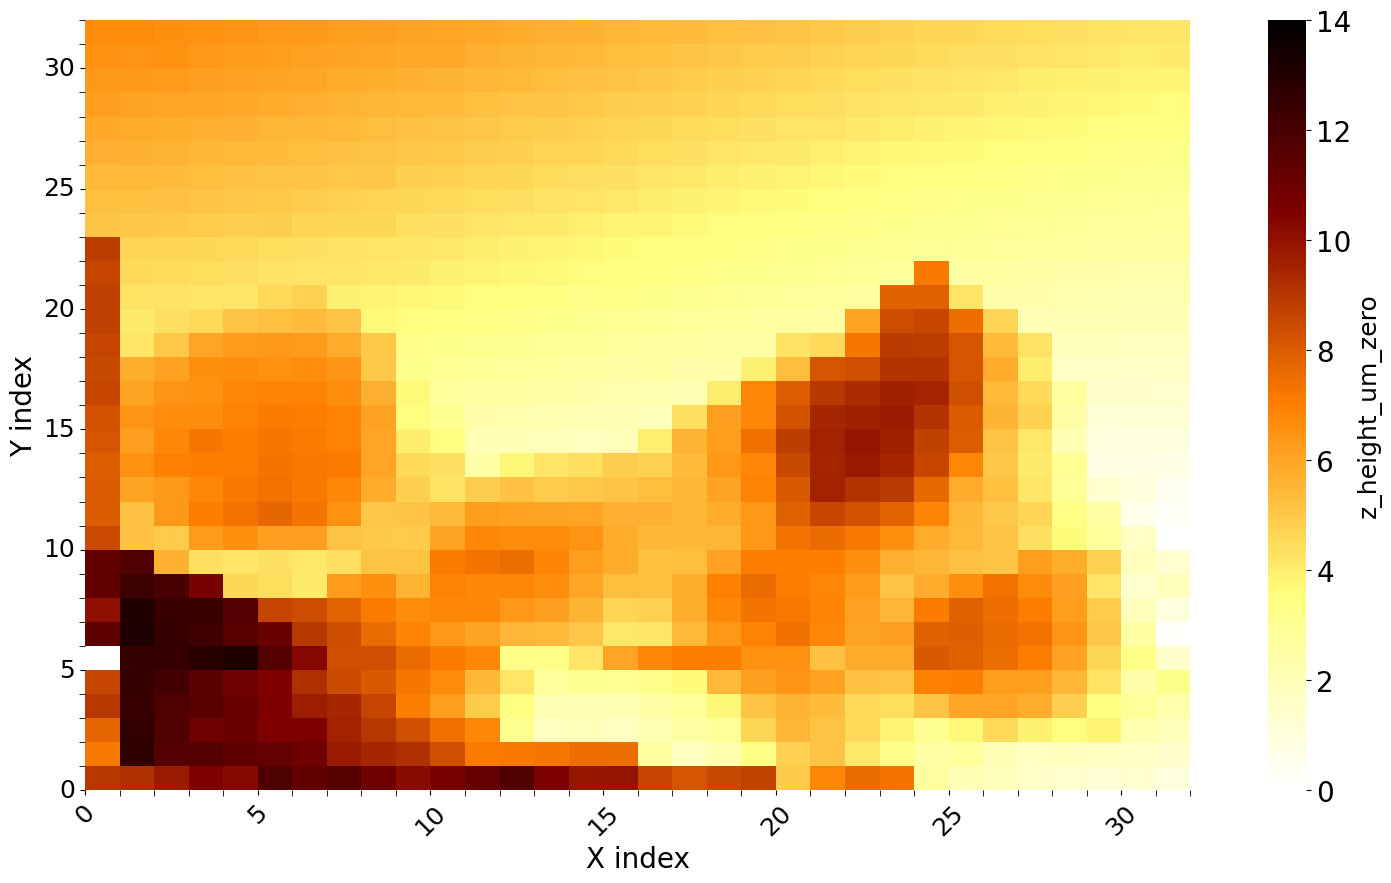

In [13]:
key1 = "z_height_um_zero"

_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key1, annot=False,
                        save_svg=True , svg_path= os.path.join(svg_dir, f'{key1}_{map_name}.svg'),
                        cmap = 'afmhot', nan = True , lastColFirst=False, zmax = 14
                        )

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 1000, zmin: 0.0238794191252724
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/ting_E0_psnex_map___2025.05.30_17.44.50.71.svg


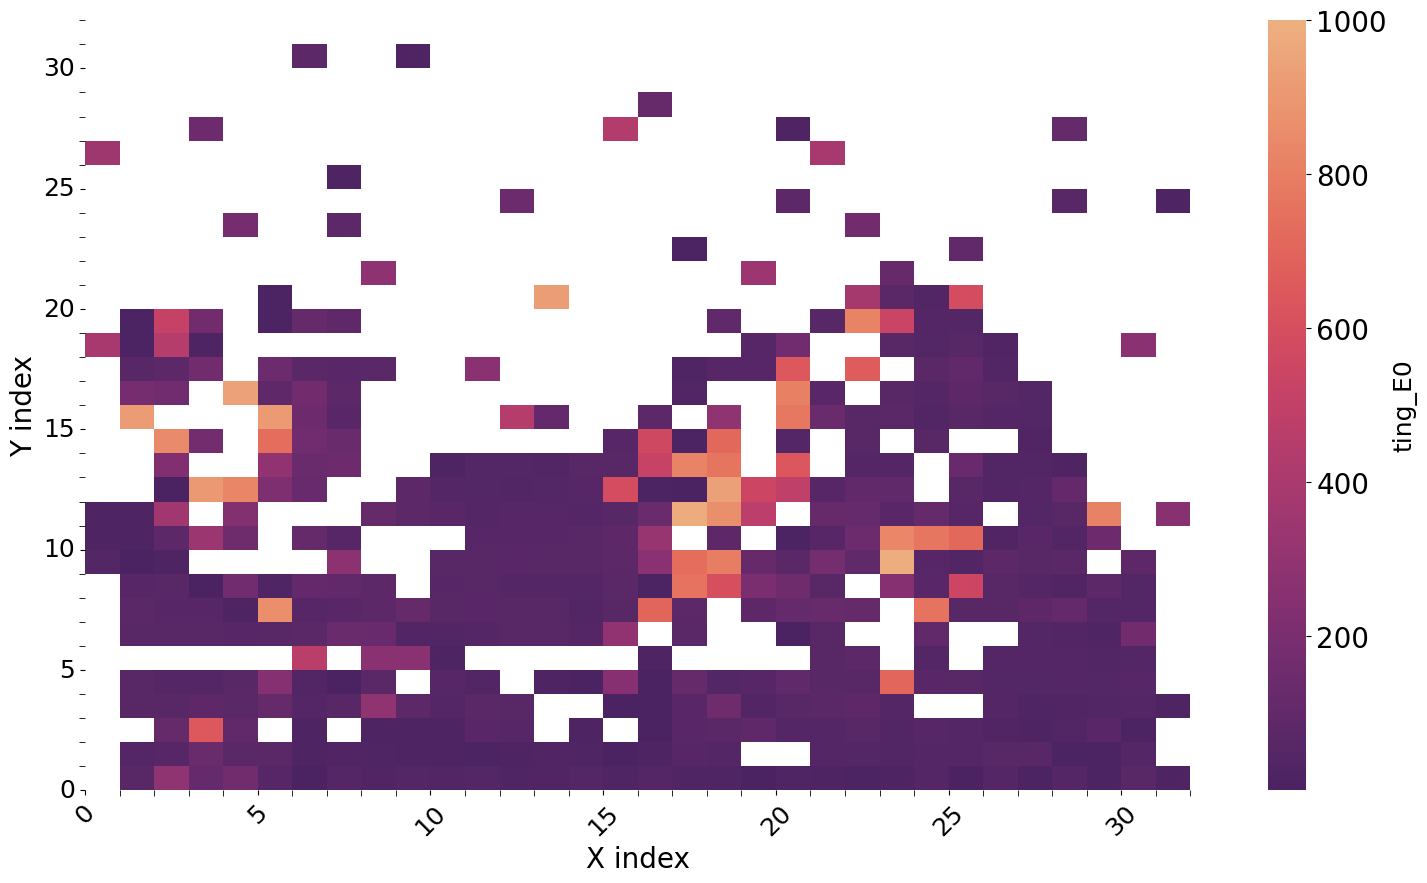

In [14]:
key2 = "ting_E0"
_ = maps.create_heatmap(df_merged_tdms_copy, value_key=key2, annot=False,
                        save_svg=False, svg_path=os.path.join(svg_dir, f'{key2}_{map_name}.svg'),
                        cmap="flare", nan= True, lastColFirst=lastColFirst, zmax = 1000)

NOTE!

To reverse the colormap so that dark colors represent lower values (zero) and light colors represent higher values, you need to append _r to the colormap name:

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/log10_ting_E0_psnex_map___2025.05.30_17.44.50.71.svg


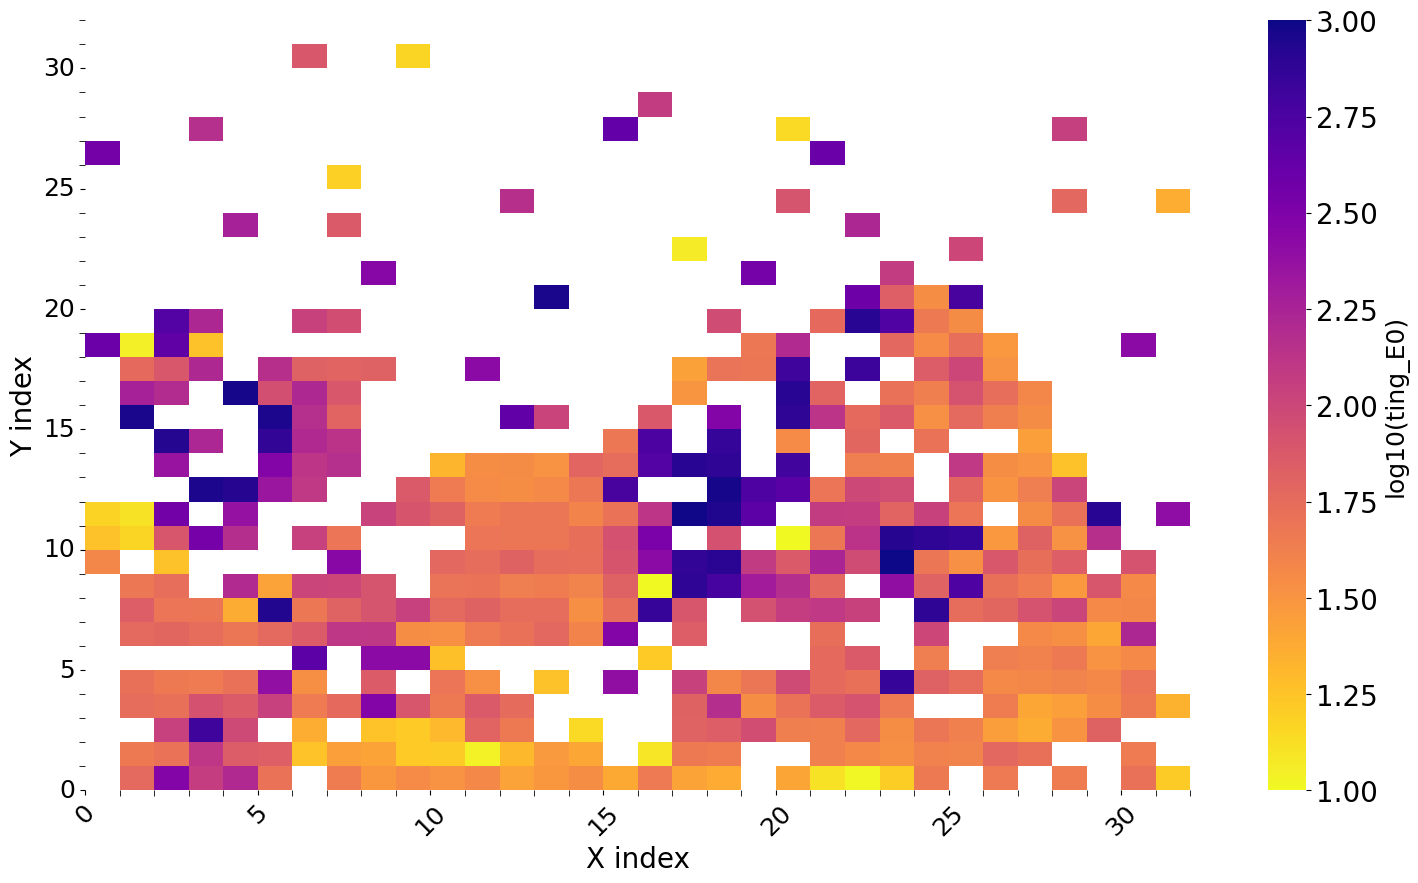

In [15]:
_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key2, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'log10_{key2}_{map_name}.svg'),
                        cmap = 'plasma', nan=True, lastColFirst=lastColFirst, zmax = 1000, zmin =10
                        )
# print (saveSVG)

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 0.4, zmin: 0.0100000000002215
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/ting_betaE_psnex_map___2025.05.30_17.44.50.71.svg


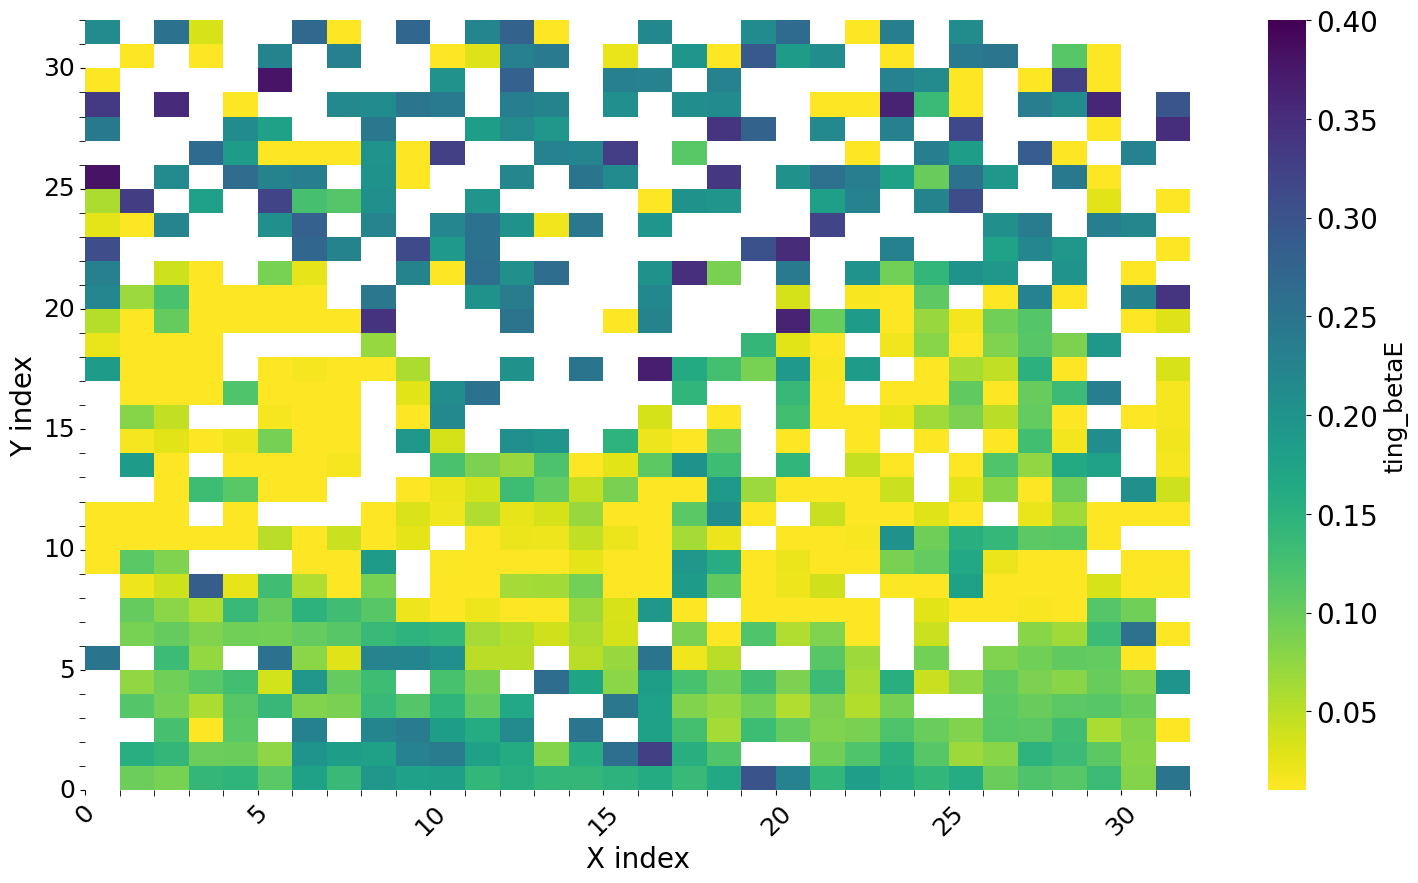

In [16]:
key3 = "ting_betaE"
_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key3, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'{key3}_{map_name}.svg'),
                        cmap = 'viridis', nan=True, lastColFirst=lastColFirst, zmax = 0.4
                        )



Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 49.79718000000001, zmin: 35.609802
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/ting_betaE_psnex_map___2025.05.30_17.44.50.71.svg


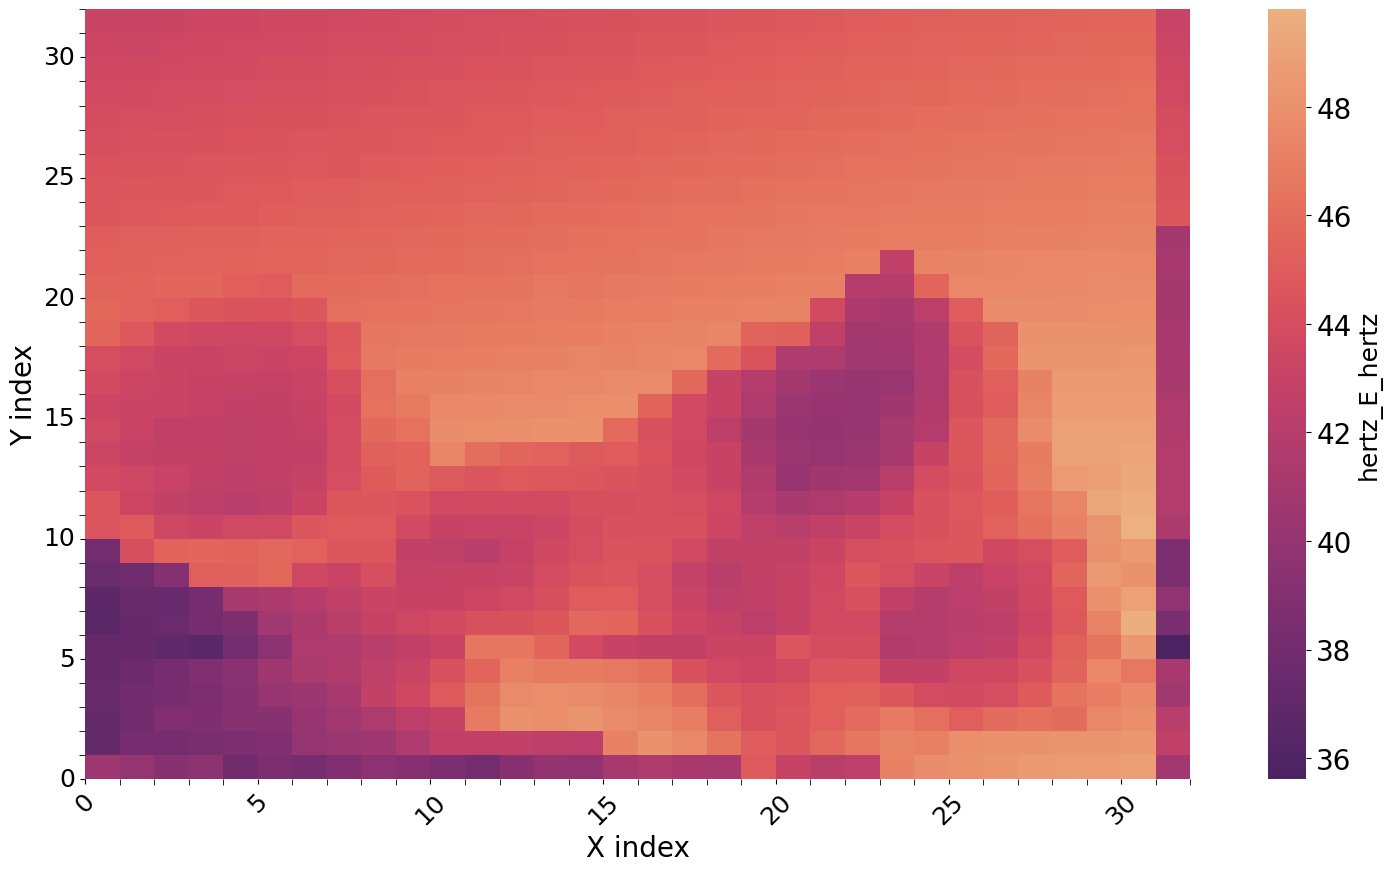

In [17]:
key_hertz = 'hertz_E_hertz'


_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key_hertz, annot=False,
                        save_svg=False, svg_path=os.path.join(svg_dir, f'{key3}_{map_name}.svg'),
                        cmap = 'flare', nan=True, lastColFirst=lastColFirst
                        )



Using provided DataFrame for heatmap
Map dimensions: 32 x 32
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/log10_ting_E0_psnex_map___2025.05.30_17.44.50.71.svg


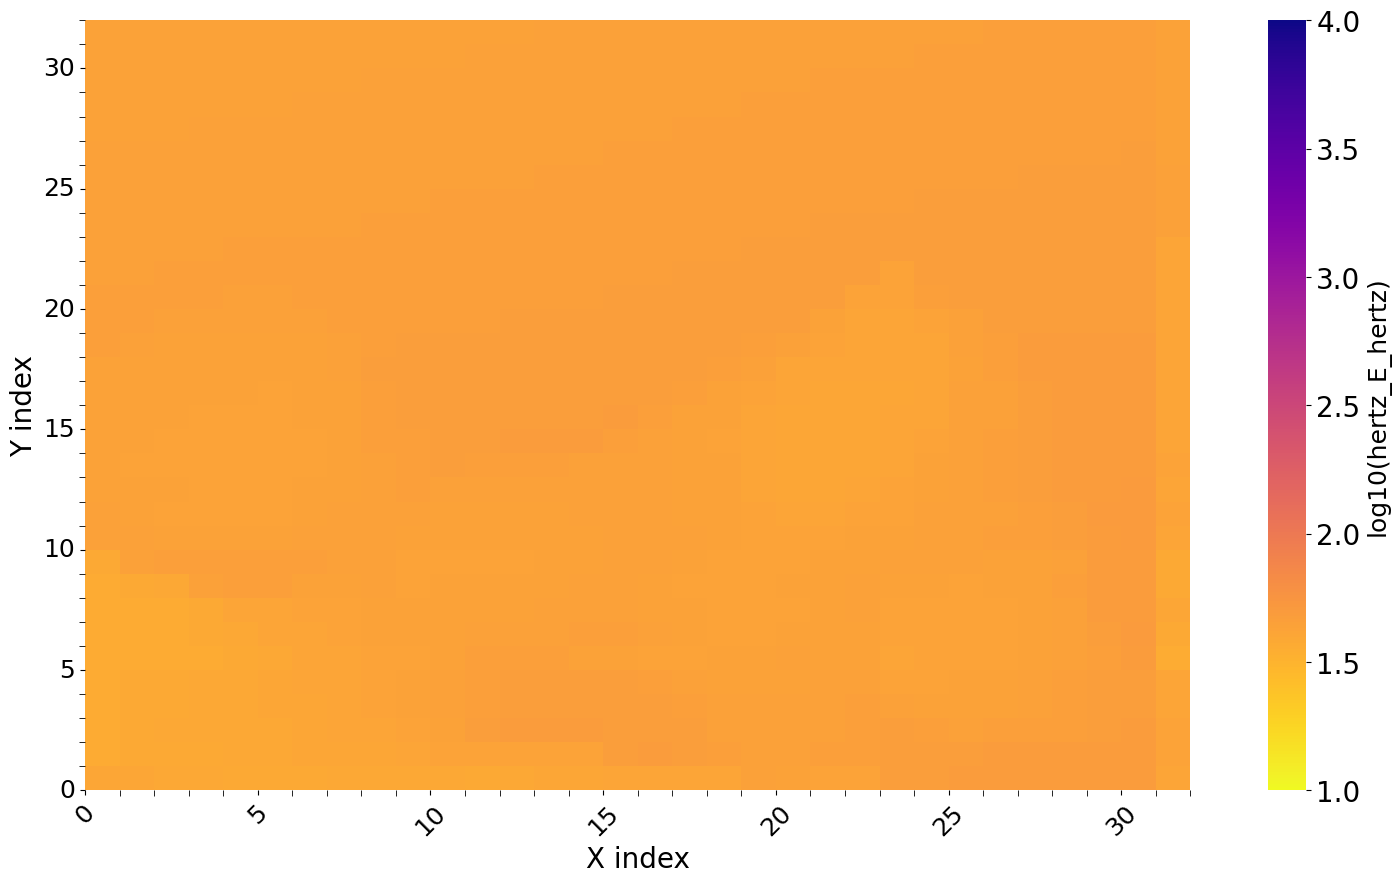

In [18]:
_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key_hertz, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'log10_{key2}_{map_name}.svg'),
                        cmap = 'plasma', nan=True, lastColFirst=lastColFirst, zmax = 10000, zmin =10
                        )

/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2286: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2286: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2286: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')


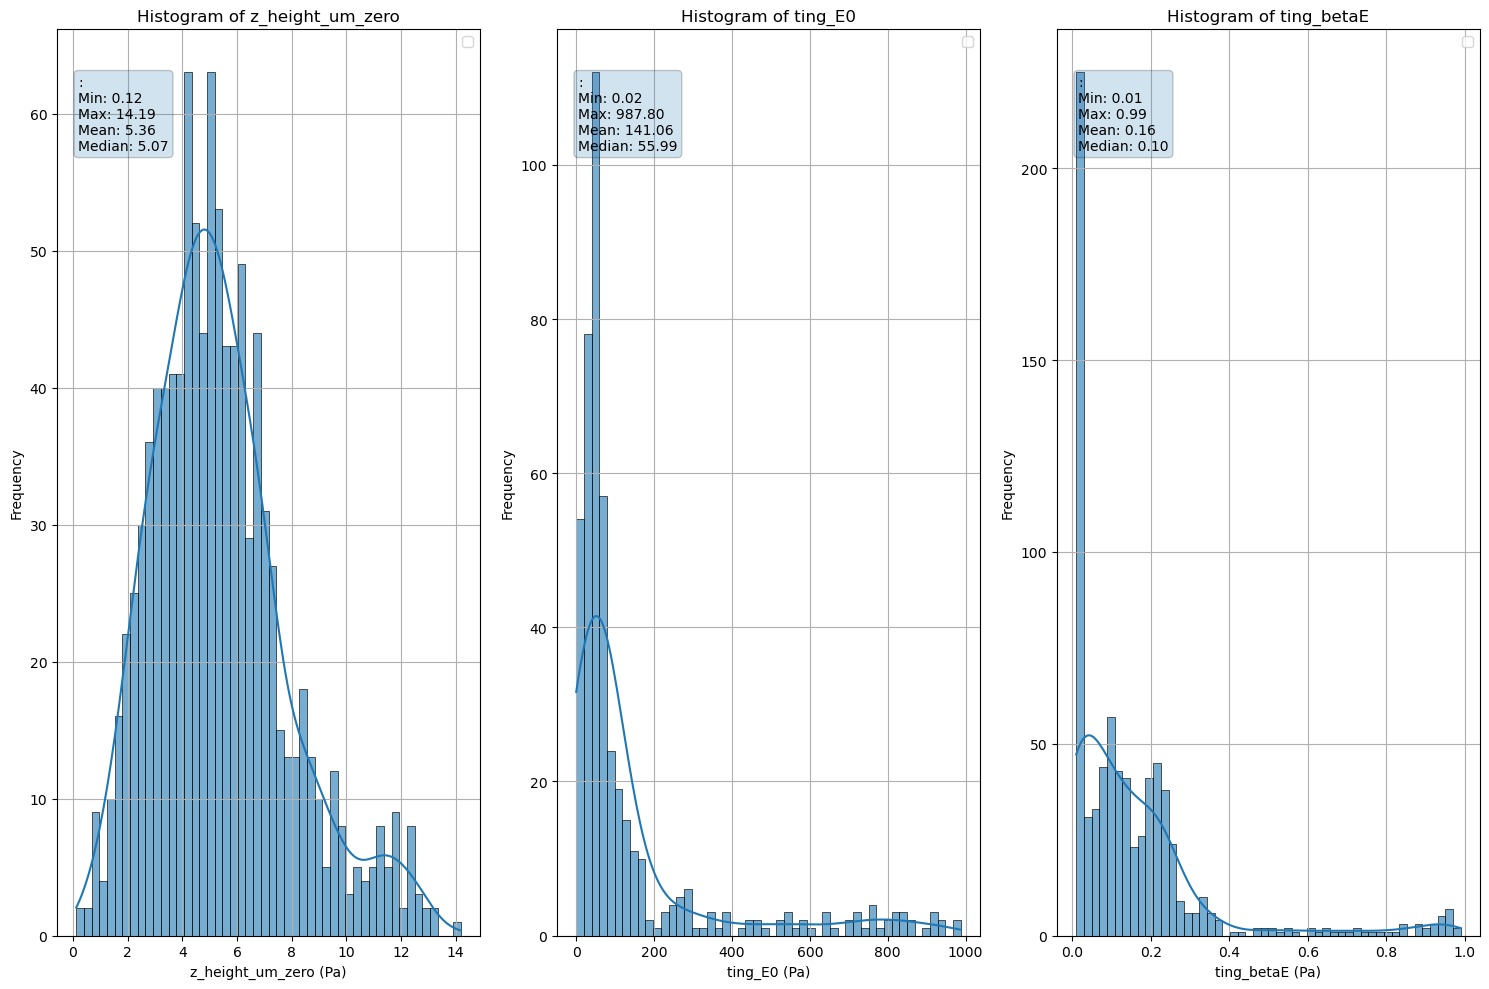

In [19]:
# generate 
# key2 = "hertz_E"
# dataframes = [(df_merged_tdms_copy, "DataFrame ting_lv"), (df_ting, "DataFrame ting_ys"), (df_ting_lv_cell2, "DataFrame ting_lv_cell2")]
dataframes = [(df_merged_tdms_copy, "")]
keys_to_plot = [key1, key2, key3]
fig, _ = maps.create_scatter_comparison(dataframes, keys_to_plot, filter_range=(0, 1000), figsize=(15, 10))

# save histogram plot to svg_dir
if saveSVG:
    print(f"Saving histogram comparison to {svg_dir}")
    fig.savefig(os.path.join(svg_dir, f'histogram_comparison_{map_name}.svg'), transparent=True)


Files processed: 1024, matches found: 1024

Time difference between first and last file HH:MM:SS:MS: 00:19:52:36
/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/results/predicted_map.svg
Analyzing map: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/analysis/psnex_map___2025.05.30_17.44.50.71_predicted.csv
y_sens_um: 3.96, x_sens_um: 5.685


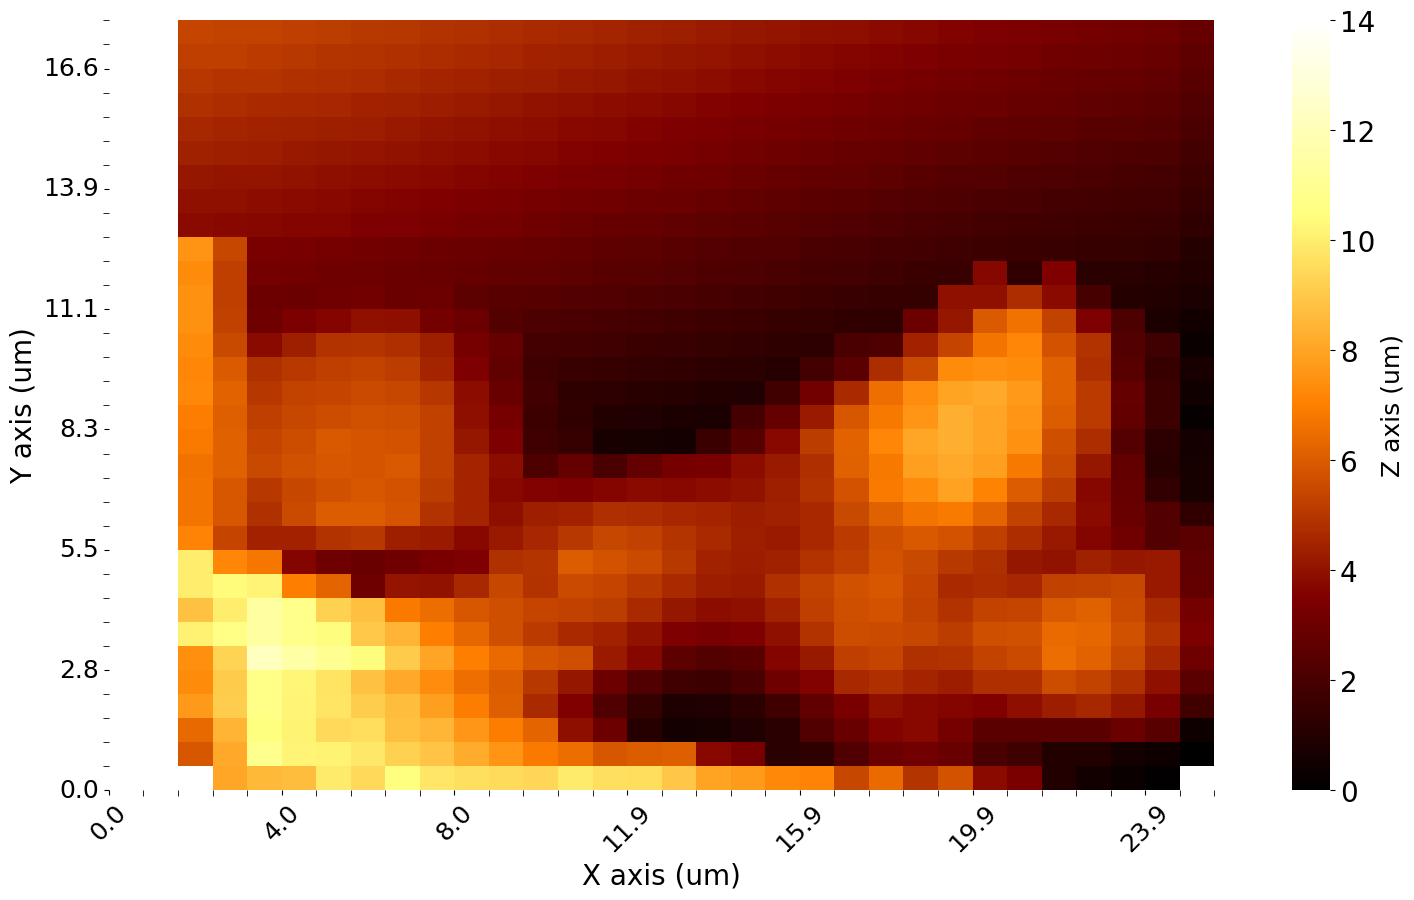

In [20]:
_ = maps.compute_time_difference('/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71')

save_path = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results'

print (os.path.join(save_path, 'results',  'predicted_map.svg'))


df_map_csv, x_axis, y_axis = maps.load_2d_map_file_csv('/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/analysis/psnex_map___2025.05.30_17.44.50.71_predicted.csv',
                                                       save_svg= False, svg_path= os.path.join(save_path, 'results')+ 'predicted_map.svg', zmax =14, lastColFirst=True, 
                                                         cmap="afmhot"
                                                       )

Analyzing map: /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/analysis/psnex_map___2025.05.30_17.44.50.71.csv
y_sens_um: 3.96, x_sens_um: 5.685


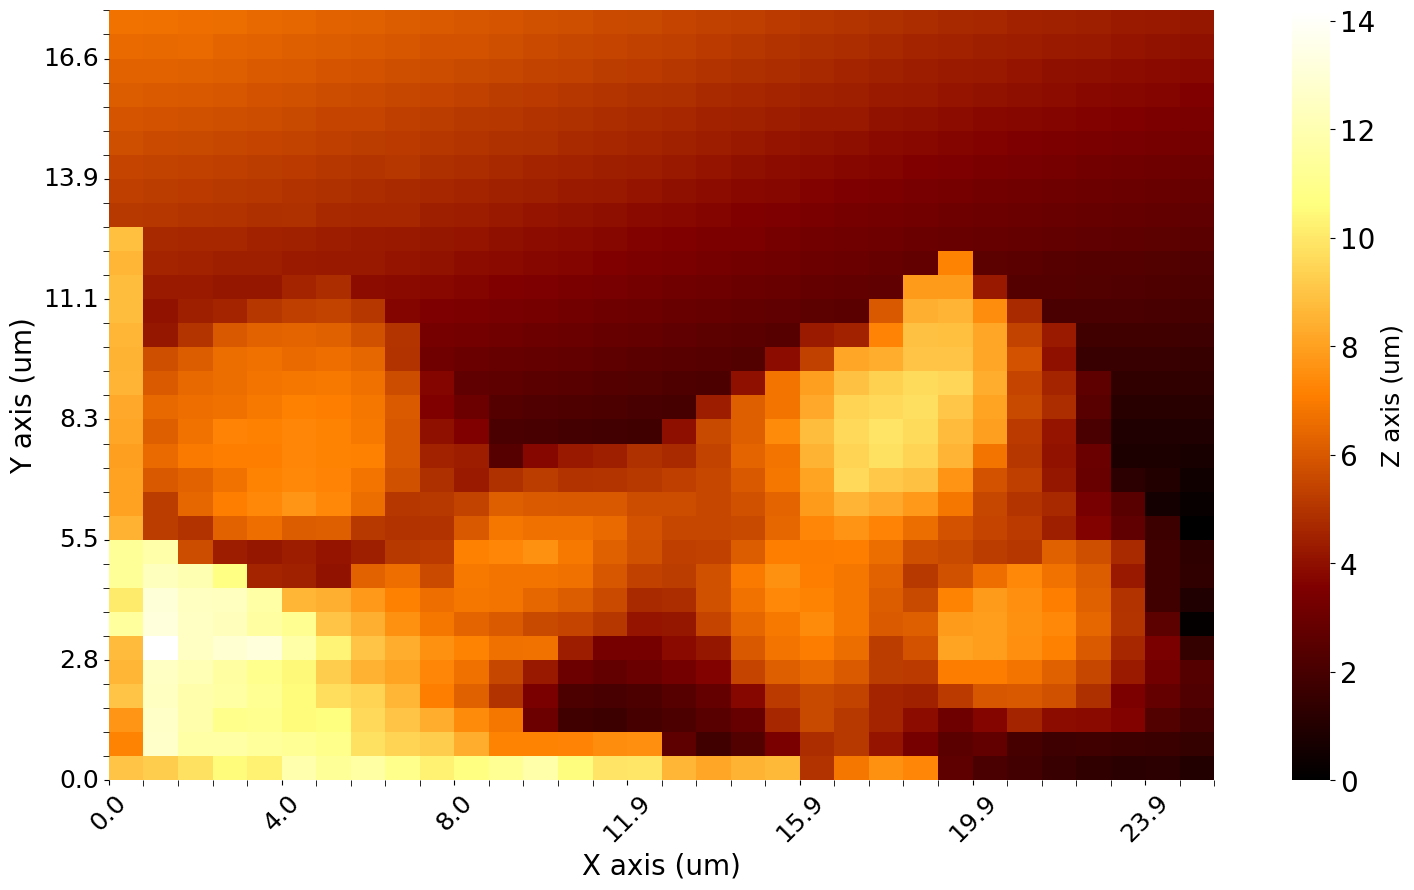

In [21]:
df_map_csv, x_axis, y_axis = maps.load_2d_map_file_csv('/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/analysis/psnex_map___2025.05.30_17.44.50.71.csv',
                                                       save_svg= False, svg_path= os.path.join(save_path, 'results')+ 'actual_map.svg',
                                                       cmap = 'afmhot'
                                                       )

# Reading a CSV file
-make sure to change file_path to filepath!

In [22]:
path_ting_lv_cell2 = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/results/ting_v3_lv_ting_results.csv'
df_ting_lv_cell2 = pd.read_csv(path_ting_lv_cell2)
df_ting_lv_cell2.head()

,filepath,file_id,curve_idx,kcanti,defl_sens,hertz_ind_geometry,hertz_tip_parameter,hertz_apply_BEC,hertz_BEC_model,hertz_fit_hline_on_baseline,...,ting_smooth_w,ting_idx_tm,ting_MAE,ting_MSE,ting_RMSE,ting_Rsquared,ting_chisq,ting_redchi,ting_v0t_app_vel,ting_v0r_ret_vel
0,/Users/evillz/Data/CTC44/2025_12_03/psnex_map_...,fcurve___2025.03.12_18.46.37.67.tdms,0,0.063,38.8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/Users/evillz/Data/CTC44/2025_12_03/psnex_map_...,fcurve___2025.03.12_18.47.27.23.tdms,0,0.063,38.8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/Users/evillz/Data/CTC44/2025_12_03/psnex_map_...,fcurve___2025.03.12_18.40.27.90.tdms,0,0.063,38.8,paraboloid,3.500000e-08,False,NaN,False,...,5.0,100.0,8.038013e-14,2.570109e-20,1.603156e-10,0.818766,-1.114470e-08,-2.786175e-09,0.000835,-0.000299
3,/Users/evillz/Data/CTC44/2025_12_03/psnex_map_...,fcurve___2025.03.12_18.40.48.88.tdms,0,0.063,38.8,paraboloid,3.500000e-08,False,NaN,False,...,5.0,207.0,-8.951428e-15,1.424337e-20,1.193456e-10,0.859189,-2.563442e-08,-6.408606e-09,0.000678,-0.000006
4,/Users/evillz/Data/CTC44/2025_12_03/psnex_map_...,fcurve___2025.03.12_18.46.24.98.tdms,0,0.063,38.8,paraboloid,3.500000e-08,False,NaN,False,...,5.0,130.0,1.392478e-11,4.116068e-20,2.028809e-10,0.831419,-2.072935e-08,-5.182337e-09,0.000768,-0.000102


In [23]:
# df_ting_ys_copy = df_ting.copy()

# FULL Implementation

In [24]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

In [25]:
# path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/results/ting_v1_psnex_map___2025.03.12_18.23.11.20_ting_results.csv'
# map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/'
# df_ting = pd.read_csv(path_ting)
# df_ting.head()

In [26]:
# map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/' # CTC 44 PFQNM. THIS
df_dict_tdms, map_x_pix, map_y_pix, params = maps.load_map_file_square_tdms(map_path)
bool_error, mismatch_indices = maps.check_map_indice_integrity(df_dict_tdms, map_x_pix, map_y_pix)
if bool_error:
    x_pos_1d, y_pos_1d, curve_index = maps.generate_xy_map_positions(map_x_pix=map_x_pix, map_y_pix=map_y_pix)
    x_indices = x_pos_1d
    y_indices = y_pos_1d
    print ('Map indices were regenerated due to integrity error')   

    # compute the time difference between files, and sort time from start to finish.
    # create a sorted dataframe based on time
    # Does not have file_id column
    df_time = maps.compute_time_difference(map_path)

    # Remove duplicates from df_time based on filepath (keep first occurrence)
    df_time = df_time.drop_duplicates(subset='filepath', keep='first')

    # Merge based on filepath - this should now be 1:1
    df_merged_tdms = pd.merge(df_dict_tdms, df_time, on='filepath', how='left')

    # create copy of df_merged_tdms to avoid SettingWithCopyWarning
    df_merged_tdms_copy = df_merged_tdms.copy()

    # # merge def_ting to df_merged_tdms based on filepath
    df_merged_tdms_copy = pd.merge(df_merged_tdms_copy, df_ting, on='file_id', how='left')

    # # insert x_indices and y_indices and curve index into df_merged_tdms
    df_merged_tdms_copy['x_index'] = x_indices
    df_merged_tdms_copy['y_index'] = y_indices
    df_merged_tdms_copy['curve_index'] = curve_index

    # Check if we have the expected number of rows
    print(f"df_map rows: {len(df_dict_tdms)}")
    print(f"df_time rows: {len(df_time)}")
    print(f"df_merged_tdms rows: {len(df_merged_tdms)}")

# of files analyzed: 1024, closest shape: 32 x 32
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  M

In [27]:
# df_merged_tdms_copy.head()

In [28]:
key = "ting_E0"
key = "z_height_um_zero"
keys_to_plot = ['z_height_um_zero', 'ting_E0', 'ting_betaE']

# for key in keys_to_plot:
    # _ = maps.create_heatmap(df_merged_tdms_copy,value_key = key, annot=False)

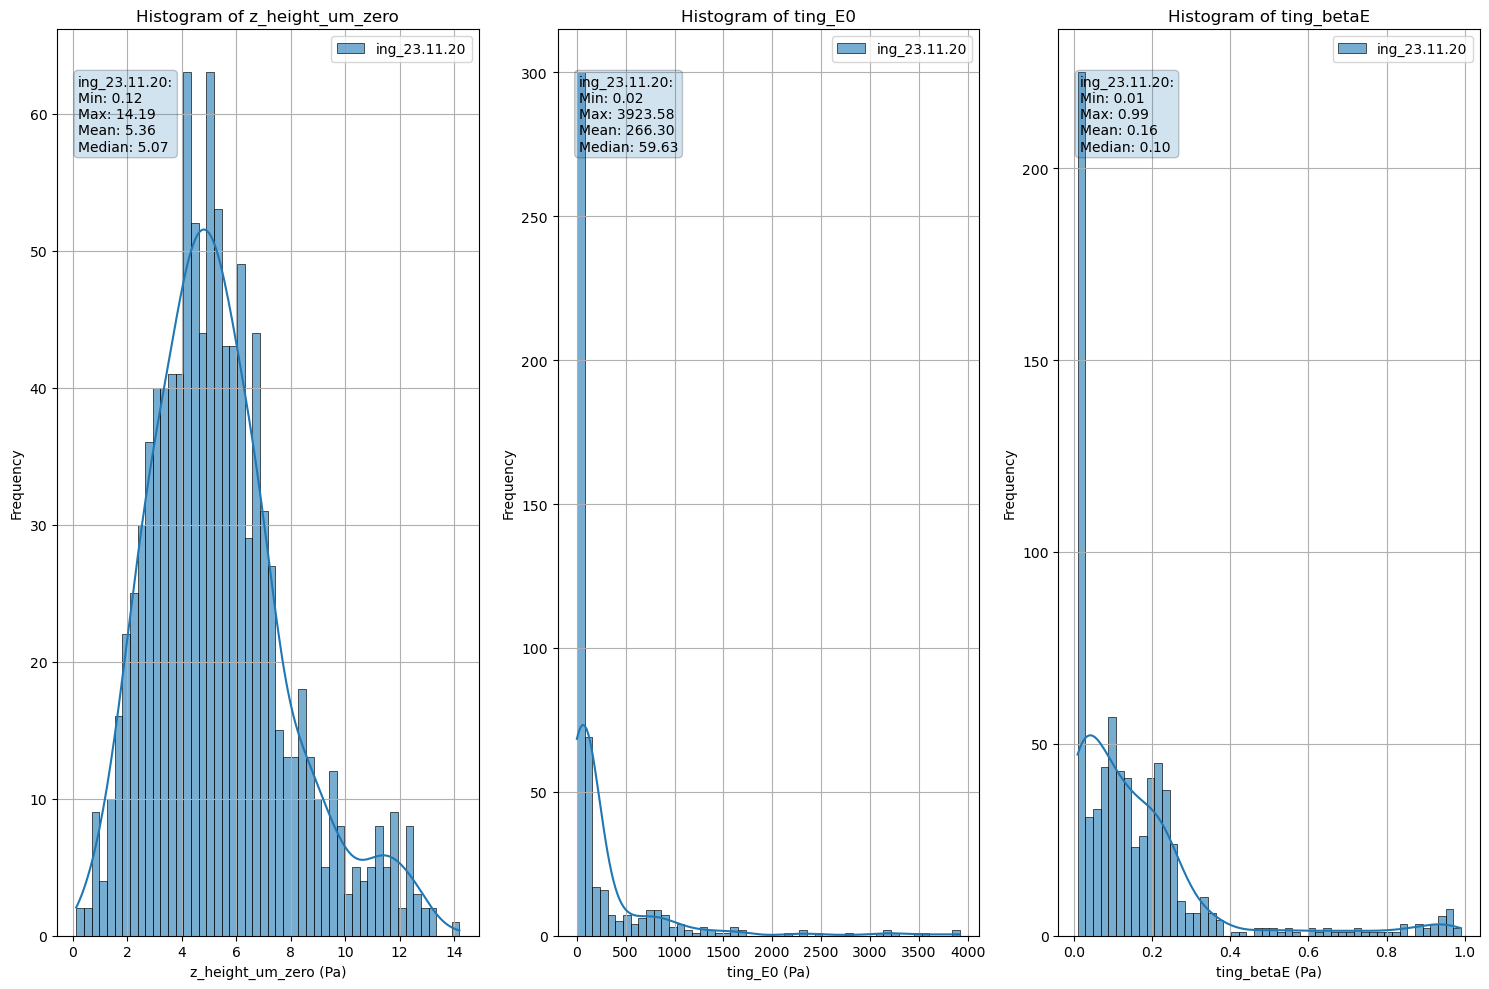

(<Figure size 1500x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Histogram of z_height_um_zero'}, xlabel='z_height_um_zero (Pa)', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of ting_E0'}, xlabel='ting_E0 (Pa)', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of ting_betaE'}, xlabel='ting_betaE (Pa)', ylabel='Frequency'>],
       dtype=object))

In [29]:
# plot the distributions of the target keys
dataframes = [(df_merged_tdms_copy, "ing_23.11.20")]
maps.create_scatter_comparison(dataframes, keys_to_plot, filter_range=(0, 4000), figsize=(15, 10))


In [30]:
# piezoimg = NANOSC_PFC_FILE.getpiezoimg()

# plt.figure(figsize=(10,10))
# plt.imshow(piezoimg[:, :, 0], cmap='afmhot', origin='lower')
# plt.show()